In [1]:
%matplotlib widget
import sys, importlib, os
import McsPy.McsData
import McsPy.McsCMOS
from McsPy import ureg, Q_

# matplotlib.pyplot will be used in these examples to generate the plots visualizing the data
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.widgets import Slider
import numpy as np
from scipy import signal
from scipy.ndimage import gaussian_filter1d

import seaborn as sns
# import datashader as ds
# import datashader.transfer_functions as tf
import pandas as pd

na = np.array
import scipy.signal
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import h5py
import os 

def detect_burst_events(signal,
                        threshold_std=5, 
                        min_separation=2000, 
                        dt=0.0004, 
                        smoothing_sigma=10,
                           baseline =None):
    """
    Detects burst events using Hilbert envelope and threshold crossings.

    Returns:
        envelope (np.array): Smoothed envelope.
        events (list): List of (start_idx, end_idx) pairs.
        intervals (list): List of (start_time, end_time) pairs in seconds.
    """
    # Hilbert envelope
    # analytic_signal = scipy.signal.hilbert(signal)
    # envelope = np.abs(analytic_signal)
    envelope= signal
    envelope = gaussian_filter1d(envelope, sigma=smoothing_sigma)
    # Thresholds
    if len(baseline)>1:
        mean_val = np.mean(envelope[baseline[0]:baseline[1]])
        std_val = np.std(envelope[baseline[0]:baseline[1]])
    else:
        mean_val = np.mean(envelope)
        std_val = np.std(envelope)
    
    high_thresh = mean_val + threshold_std * std_val
    low_thresh = mean_val + (threshold_std - 2) * std_val  # hysteresis: end at lower threshold

    # Find regions above threshold
    above = envelope > high_thresh
    above_indices = np.where(above)[0]

    events = []
    
    if len(above_indices) == 0:
        return envelope, events, []

    # Initialize first event
    start_idx = above_indices[0]
    prev_idx = start_idx
    windows = []
    for idx in above_indices[1:]:
        if idx - prev_idx > min_separation:
            # Close the previous event
            end_idx = prev_idx
            events.append((start_idx, end_idx))
            windows.append(signal[start_idx:end_idx])
            # Start a new event
            start_idx = idx
        prev_idx = idx
    # print(len(windows),len(events))
    # Add the last event
    events.append((start_idx, prev_idx))
    windows.append(signal[start_idx:prev_idx])
    # Convert to time intervals
    intervals = [(start_idx * dt, end_idx * dt) for start_idx, end_idx in events]

    
    return envelope,windows,intervals

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

class BurstBatchReviewer:
    def __init__(self, events, dt=0.0004, batch_size=36):
        """
        events: list of (signal_window,) – each is a short array for a burst
        """
        self.events = events
        self.dt = dt
        self.batch_size = batch_size
        self.current_batch = 0
        self.accepted = {i: True for i in range(len(events))}  # All accepted by default

        self.fig = None
        self.axs = None
        self.cid = None

        self.out = widgets.Output()
        self.button_return = widgets.Button(description="⬅️ Return", button_style="warning")
        self.button_next = widgets.Button(description="➡️ Next batch")
        self.button_finish = widgets.Button(description="✅ Finish", button_style="success")
        self.status = widgets.Label()

        self.button_next.on_click(self.next_batch)
        self.button_return.on_click(self.return_batch)
        self.button_finish.on_click(self.finish_review)

        control_panel = widgets.HBox([self.button_return, self.button_next, self.button_finish])
        display(self.status, control_panel, self.out)

        self.show_batch()

    def show_batch(self):
        with self.out:
            clear_output(wait=True)
            self.start_i = self.current_batch * self.batch_size
            self.end_i = min(self.start_i + self.batch_size, len(self.events))
            self.batch_events = self.events[self.start_i:self.end_i]

            if not self.batch_events:
                print("✅ All events reviewed.")
                print(f"Accepted: {len(self.accepted_indices)} / {len(self.events)}")
                return

            n_rows, n_cols = 6, 6
            self.fig, self.axs = plt.subplots(n_rows, n_cols, figsize=(18, 12))
            self.axs = self.axs.flatten()

            for i, (event, ax) in enumerate(zip(self.batch_events, self.axs)):
                t = np.arange(len(event)) * self.dt
                ax.plot(t, event, alpha=0.6)
                idx = self.start_i + i
                ax.set_title(f"Event #{idx}", fontsize=8)
                self.update_axes_border(ax, idx)

            for j in range(len(self.batch_events), len(self.axs)):
                self.axs[j].axis('off')

            self.fig.tight_layout()
            self.cid = self.fig.canvas.mpl_connect('button_press_event', self.on_click)
            self.status.value = f"Reviewing events {self.start_i} to {self.end_i - 1}"
            plt.show()

    def update_axes_border(self, ax, idx):
        if self.accepted.get(idx, True):
            color = 'green'
        else:
            color = 'red'
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

    def on_click(self, event):
        if event.inaxes not in self.axs:
            return
        ax = event.inaxes
        ax_idx = list(self.axs).index(ax)
        global_idx = self.start_i + ax_idx
        self.accepted[global_idx] = not self.accepted.get(global_idx, True)
        self.update_axes_border(ax, global_idx)
        self.fig.canvas.draw_idle()

    def next_batch(self, b=None):
        if self.current_batch < (len(self.events) - 1) // self.batch_size:
            self.current_batch += 1
        self.show_batch()

    def return_batch(self, b=None):
        if self.current_batch > 0:
            self.current_batch -= 1
        self.show_batch()

    def finish_review(self, b=None):
        with self.out:
            clear_output(wait=True)
            self.final_accepted_indices = self.accepted_indices
            print("✅ Review complete.")
            print(f"Total events reviewed: {len(self.events)}")
            print(f"Accepted events: {len(self.accepted_indices)}")
        if self.fig and self.cid:
            self.fig.canvas.mpl_disconnect(self.cid)
            self.cid = None
        self.status.value = "Review finished."

    @property
    def accepted_indices(self):
        return sorted([idx for idx, val in self.accepted.items() if val])

In [2]:
# Overview of all possible recordings 
rec_table = pd.read_csv('/mnt/server_epl/SCN1A/R1648H-analysis/recordings-main2.csv',delimiter=';')

/tmp/ipykernel_1133141/1152841857.py:2: DtypeWarning: Columns (4,15,16,23) have mixed types. Specify dtype option on import or set low_memory=False.
  rec_table = pd.read_csv('/mnt/server_epl/SCN1A/R1648H-analysis/recordings-main2.csv',delimiter=';')


In [3]:
rec_table

,date,mouse age,mouseID,slice,Valid,genotype,Sex,recording,protocol,duration,...,Unnamed: 16374,Unnamed: 16375,Unnamed: 16376,Unnamed: 16377,Unnamed: 16378,Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383
0,28.10.24,P14,1,slice1,True,wt,?,1.0,5-10-10,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,28.10.24,P14,1,slice1,True,wt,?,2.0,5-10-10,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28.10.24,P14,1,slice1,True,wt,?,3.0,5-10-10,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28.10.24,P14,1,slice2,True,wt,?,1.0,5-10-10,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,28.10.24,P14,1,slice2,True,wt,?,2.0,5-10-10,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,26.3.25,P20,15,slice5,NaN,wt,male,NaN,10-40,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,26.3.25,P20,15,slice6,NaN,wt,male,1.0,5-10-10,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178,26.3.25,P20,15,slice6,NaN,wt,male,2.0,10-40,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179,26.3.25,P20,15,slice7,NaN,wt,male,NaN,5-10-10,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Get channel mapping
file_name = '/mnt/server_epl/SCN1A/R1648H-export/20-3-25/slice2/2025-03-20T12-08-00McsRecording.h5'
channel_raw_data = McsPy.McsData.RawData(file_name)    
channels = []
channels_dict ={}
for i,ch_n in enumerate(list(channel_raw_data.recordings[0].analog_streams[0].channel_infos.keys())):
    channels.append(channel_raw_data.recordings[0].analog_streams[0].channel_infos[ch_n].label)#.recordings[0].segment_streams[0].segment_entity.keys()
    # channels_dict[int(i)]= channel_raw_data.recordings[0].analog_streams[0].channel_infos[i].label
    channels_dict[channel_raw_data.recordings[0].analog_streams[0].channel_infos[ch_n].label]= int(i)#

Recording_0 <HDF5 group "/Data/Recording_0" (1 members)>
Stream_0 <HDF5 group "/Data/Recording_0/AnalogStream/Stream_0" (3 members)>
ChannelData <HDF5 dataset "ChannelData": shape (252, 3592000), type "<i4">
ChannelDataTimeStamps <HDF5 dataset "ChannelDataTimeStamps": shape (1, 3), type "<i8">
InfoChannel <HDF5 dataset "InfoChannel": shape (252,), type "|V108">


In [10]:
#set img path 
i_num =157#157#157#165
rec_table.iloc[i_num]
# rec_table.image_path = '21-3-25\slice2\stack'
img_path = '/mnt/server_epl/SCN1A/R1648/'+rec_table.iloc[i_num].image_path + '/Fused.tif'
img_path =img_path.replace('\\','/')
print(img_path)
print(rec_table.iloc[i_num])

/mnt/server_epl/SCN1A/R1648/21-3-25/slice6/stack/Fused.tif
date              21.3.25
mouse age             P18
mouseID                13
slice              slice6
Valid                 NaN
                   ...   
Unnamed: 16379        NaN
Unnamed: 16380        NaN
Unnamed: 16381        NaN
Unnamed: 16382        NaN
Unnamed: 16383        NaN
Name: 157, Length: 16384, dtype: object


<Axes: xlabel='e_pos_x', ylabel='e_pos_y'>

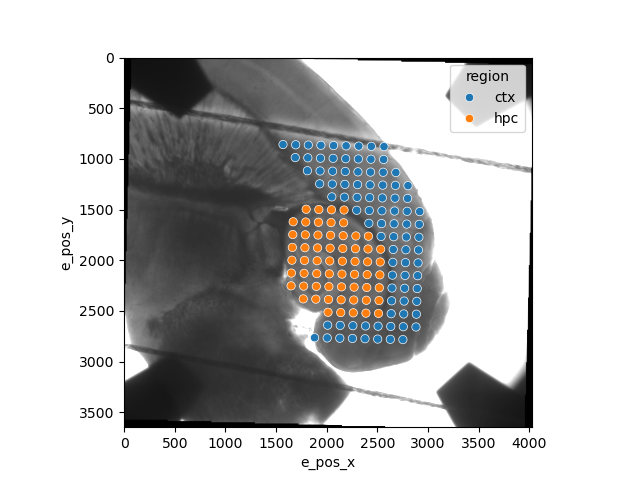

In [11]:
detection_path = '/mnt/server_epl/SCN1A/R1648/'+rec_table.iloc[i_num].image_path + '/labeled_electrodes.csv'
detection_path =detection_path.replace('\\','/')
ch_detection =pd.read_csv(detection_path)
regions= na(ch_detection['region'])
ch_labels = na(ch_detection['e_label'])
valid_channels = [channels_dict[ch] for ch in ch_labels]

valid_channels,ch_ind = np.unique(valid_channels,return_index=True)
regions = regions[ch_ind]
ch_labels = ch_labels[ch_ind]

ch_srt_index = np.argsort(valid_channels)
valid_channels = valid_channels[ch_srt_index]
regions = regions[ch_srt_index]
plt.figure()
I = plt.imread(img_path)
plt.imshow(I,cmap='gray',vmax=5000)
sns.scatterplot(x='e_pos_x',y='e_pos_y', hue='region',data=ch_detection)

In [13]:
from datetime import datetime
path = rec_table.iloc[i_num].path.replace('\\','/')
file_name = rec_table.iloc[i_num].file_name
print('Protocol',rec_table.iloc[i_num].protocol,'Recording',rec_table.iloc[i_num].recording)
os.path.join(path,file_name)
slice_ =path.split('/')[-1]
date =path.split('/')[0]
dt = datetime.strptime(date, '%d-%m-%y')
date = dt.strftime('%d-%m-%y')
print(date)
filt_file_name = 'R1648H_'+date+'_'+slice_+'_'+file_name+'.h5_filtered.h5'
# filt_path = '../data/R1648H_filt2'
filt_path = '/mnt/server_epl/SCN1A/R1648H_filt'
target_file = os.path.join(filt_path,filt_file_name).replace('\\','/')


Protocol 10-40 Recording 2.0
21-03-25


In [14]:
mv_scale_factor =  1000000
with h5py.File(target_file, 'r') as f:
    # print(f.keys())
    # print(f['data'].shape)
    filt = f['data'][:600000,valid_channels]
    # subsampling_rate = f['resampled_rate']
    subsampling_rate = na(f['resampled_rate'])
    adc_step = na(f['scale'])
print(subsampling_rate)
subsampling_rate = subsampling_rate
print('subsampling_rate',subsampling_rate)
# filt =filt[:,valid_channels]
# need to sort to make it compatible with what's read out from hdf5
# ch_srt_index = np.argsort(np.unique(valid_channels))
# valid_channels=valid_channels[np.argsort(valid_channels)]
# regions = regions[ch_srt_index]

800
subsampling_rate 800


In [16]:
# from datetime import datetime
# path = rec_table.iloc[i_num].path.replace('\\','/')
# file_name = rec_table.iloc[i_num].file_name
# print('Protocol',rec_table.iloc[i_num].protocol,'Recording',rec_table.iloc[i_num].recording)
# os.path.join(path,file_name)
# slice_ =path.split('/')[-1]
# date =path.split('/')[0]
# dt = datetime.strptime(date, '%d-%m-%y')
# date = dt.strftime('%d-%m-%y')
# print(date)

# filt_file_name = 'R1648H_'+date+'_'+slice_+'_'+file_name+'.h5_filtered.h5'
# filt_path = '../data/R1648H_filt2'
# # filt_path = '/mnt/server_epl/SCN1A/R1648H_filt'
# target_file = os.path.join(filt_path,filt_file_name).replace('\\','/')
# mv_scale_factor =  1000000
# with h5py.File(target_file, 'r') as f:
#     # print(f.keys())
#     # print(f['data'].shape)
#     filt_ = f['data'][:600000,valid_channels]
#     # subsampling_rate = f['resampled_rate']
#     subsampling_rate = na(f['resampled_rate'])
#     adc_step = na(f['scale'])
# print(subsampling_rate)
# subsampling_rate = subsampling_rate
# print('subsampling_rate',subsampling_rate)
# # filt =filt[:,valid_channels]
# # need to sort to make it compatible with what's read out from hdf5
# # ch_srt_index = np.argsort(np.unique(valid_channels))
# # valid_channels=valid_channels[np.argsort(valid_channels)]
# # regions = regions[ch_srt_index]

In [154]:
# region = 'ctx'
# plt.figure(figsize=(15,3))
# subsplot = 10
# plt.plot(np.arange(0,len(filt[::subsplot]))*(1/(subsampling_rate/subsplot)),filt[::subsplot,regions==region][:,:]+10000,alpha=0.3)
# # [plt.axvspan(b[0],b[1]) for b in na(intervals)];
# # plt.show()
# try:
#     detected_events = pd.read_csv('../data/R1648H/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
#     [plt.axvspan(na(detected_events.iloc[i].intervals_start),na(detected_events.iloc[i].intervals_end),alpha=0.2) for i in range(len(detected_events))];
# except:
#     print('Not detected yet')
# region = 'hpc'
# plt.plot(np.arange(0,len(filt[::subsplot]))*(1/(subsampling_rate/subsplot)),filt[::subsplot,regions==region][:,:],alpha=0.9)
# # [plt.axvspan(b[0],b[1]) for b in na(intervals)];
# # plt.show()
# try:
#     detected_events = pd.read_csv('../data/R1648H/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
#     [plt.axvspan(na(detected_events.iloc[i].intervals_start),na(detected_events.iloc[i].intervals_end),alpha=0.2) for i in range(len(detected_events))];
# except:
#     print('Not detected yet')

In [155]:
# import matplotlib
# matplotlib.pyplot.close()

In [203]:
filt_.shape

(600000, 149)

(0.0, 500.0)

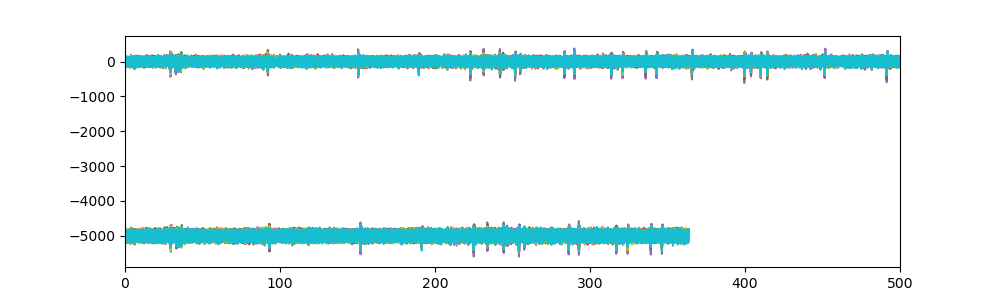

In [211]:
plt.figure(figsize=(10,3))
plt.plot(np.arange(0,len(filt[::subsplot]))*(1/(800)),filt[:,:10]);
plt.plot(np.arange(0,len(filt[::subsplot]))*(1/(1650)),filt_[:,:10]-5000);
# [plt.axvspan(na(detected_events.iloc[i].intervals_start),na(detected_events.iloc[i].intervals_end),alpha=0.2) for i in range(len(detected_events))];
plt.xlim(0,500)

In [191]:
subsampling_rate

np.float64(32.0)

NameError: name 'filt_' is not defined

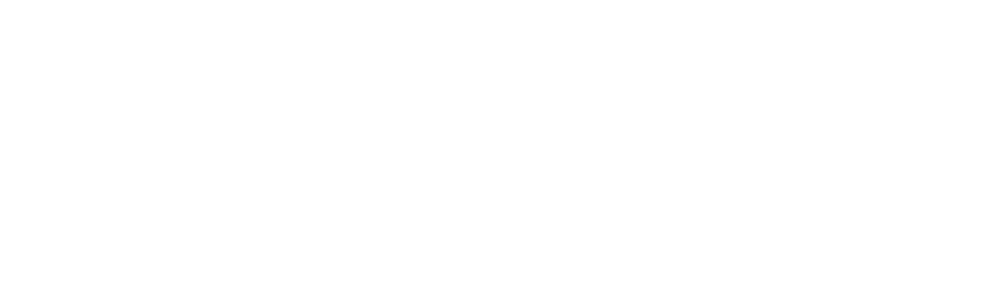

In [15]:
region = 'ctx'
plt.figure(figsize=(10,3))
subsplot = 1
plt.plot(np.arange(0,len(filt[::subsplot]))*(1/(subsampling_rate/subsplot)),filt_[::subsplot,regions==region],alpha=0.3)
plt.show()
try:
    detected_events = pd.read_csv('../data/R1648H/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
    [plt.axvspan(na(detected_events.iloc[i].intervals_start),na(detected_events.iloc[i].intervals_end),alpha=0.2) for i in range(len(detected_events))];
except:
    print('Not detected yet')

In [168]:
np.max(np.arange(0,len(filt[::subsplot])) *(1/(subsampling_rate)))

np.float64(124.96875)

In [ ]:
np.max(np.arange(0,len(filt[::subsplot])) *(1/(subsampling_rate)))

In [167]:
subsampling_rate

np.float64(32.0)

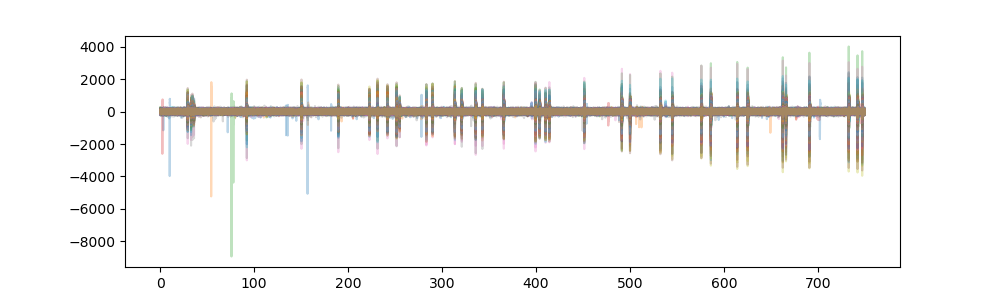

In [18]:
region = 'ctx'
plt.figure(figsize=(10,3))
subsplot = 1
plt.plot(np.arange(0,len(filt[::subsplot]))*(1/(subsampling_rate/subsplot)),filt[::subsplot,regions==region],alpha=0.3)
plt.show()
try:
    detected_events = pd.read_csv('../data/R1648H/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
    # [plt.axvspan(na(detected_events.iloc[i].intervals_start),na(detected_events.iloc[i].intervals_end),alpha=0.2) for i in range(len(detected_events))];
except:
    print('Not detected yet')

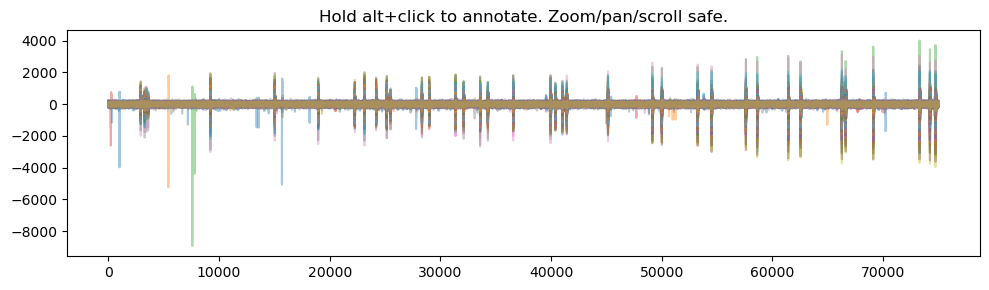

Output()

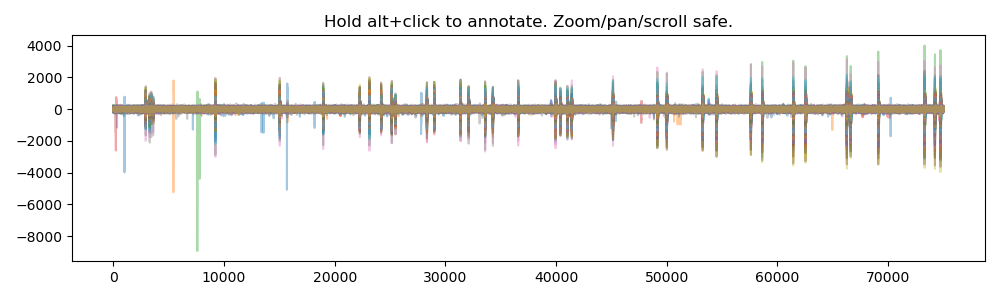

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from IPython.display import Javascript, display
def annotate_timeseries_intervals(signal, times=None, modifier_key='alt'):
    """
    Interactive annotation of time intervals in Jupyter.
    - Hold keyboard modifier (e.g. Alt, Ctrl) + Left-click to mark intervals.
    - Zoom/pan/scroll work normally.
    
    Parameters:
        signal : 1D numpy array
        times  : optional time axis
        modifier_key : str, one of 'alt', 'control', 'shift', 'meta'
    """
    if times is None:
        times = np.arange(len(signal))

    intervals = []
    patches = []
    click_state = {'start': None}
    done_flag = widgets.Output()

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(times, signal, alpha=0.4)
    # plt.plot(np.arange(0,len(filt[::subsplot]))*(1/(subsampling_rate/subsplot)),filt[::subsplot,regions==region],alpha=0.3)

    ax.set_title(f"Hold {modifier_key}+click to annotate. Zoom/pan/scroll safe.")
    plt.tight_layout()
    display(fig)

    output = widgets.Output()

    def onclick(event):
        if event.button != 1 or not event.inaxes:
            return
        if event.key != modifier_key:
            return

        x = event.xdata
        if click_state['start'] is None:
            click_state['start'] = x
            with output:
                clear_output()
                print(f"Start: {x:.3f} — now {modifier_key}+click to mark end.")
        else:
            start = click_state['start']
            end = x
            if start > end:
                start, end = end, start
            patch = ax.axvspan(start, end, color='red', alpha=0.3)
            intervals.append((start, end))
            patches.append(patch)
            fig.canvas.draw()
            click_state['start'] = None
            with output:
                clear_output()
                print(f"Interval added: [{start:.3f}, {end:.3f}]")

    # Buttons
    clear_btn = widgets.Button(description="Clear all")
    undo_btn = widgets.Button(description="Undo")
    done_btn = widgets.Button(description="Done")

    def clear_clicked(b):
        intervals.clear()
        for p in patches:
            p.remove()
        patches.clear()
        fig.canvas.draw()
        click_state['start'] = None
        with output:
            clear_output()
            print("All intervals cleared.")

    def undo_clicked(b):
        if intervals and patches:
            intervals.pop()
            patches.pop().remove()
            fig.canvas.draw()
            with output:
                clear_output()
                print("Last interval removed.")
        click_state['start'] = None

    def done_clicked(b):
        fig.canvas.mpl_disconnect(cid)
        with output:
            clear_output()
            print("Annotation complete.")
        done_flag.intervals = intervals
    def on_key(event):
        if event.key not in ['left', 'right']:
            return
        xlim = ax.get_xlim()
        shift = (xlim[1] - xlim[0]) * 0.5
        if event.key == 'left':
            ax.set_xlim(xlim[0] - shift, xlim[1] - shift)
        elif event.key == 'right':
            ax.set_xlim(xlim[0] + shift, xlim[1] + shift)
    # def on_draw(event):
    #     display(Javascript('''
    #         setTimeout(() => {
    #             document.querySelector("div.jupyter-widgets canvas").focus();
    #         }, 10);
    #     '''))
        
    # fig.canvas.mpl_connect('draw_event', on_draw)
    fig.canvas.draw_idle()
    clear_btn.on_click(clear_clicked)
    undo_btn.on_click(undo_clicked)
    done_btn.on_click(done_clicked)
     # Workaround: ensure plot stays focused

    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    fig.canvas.mpl_connect('key_press_event', on_key)
    display(widgets.HBox([undo_btn, clear_btn, done_btn]), output)

    return intervals

sub_sampl = 100
y= filt[::subsplot,regions==region]#/np.max(filt[::subsplot,regions==region],0)#+np.arange(0,np.sum(regions==region))*300
# y= y+np.arange(0,np.sum(regions==region))*300
# plt.plot(np.arange(0,len(filt[::subsplot]))*(1/(subsampling_rate/subsplot)),y,alpha=0.8);
intervals = annotate_timeseries_intervals(y, times=np.arange(0,len(y))*(1/(subsampling_rate/sub_sampl)))

In [58]:
if len(intervals)==0:
    intervals =[[np.nan,np.nan],];

In [42]:
# intervals =[[np.nan,np.nan],];

In [38]:
detected_evetns = pd.DataFrame({'intervals_start':na(intervals)[:,0],'intervals_end':na(intervals)[:,1]})

detected_evetns['date']=rec_table.loc[i_num].date
detected_evetns['file_name']=rec_table.loc[i_num].file_name
detected_evetns['genotype']=rec_table.loc[i_num].genotype
detected_evetns['protocol']=rec_table.iloc[i_num].protocol
detected_evetns['Recording']=rec_table.iloc[i_num].recording
detected_evetns['slice_type']=rec_table.iloc[i_num]['slice type']
detected_evetns['slice_number']=rec_table.loc[i_num].slice
# detected_evetns['channels'] = np.where(regions==region)[0]
              
detected_evetns['region'] = region
detected_evetns.to_csv('../data/R1648H/detected_events/'+'detected_events_'+str(region)+'_'+file_name)

In [314]:
detected_evetns

,intervals_start,intervals_end,date,file_name,genotype,protocol,Recording,slice_type,slice_number,region
0,40.986841,70.613855,20.3.25,2025-03-20T15-02-51McsRecording,?,5-10-10,4.0,horizontal,slice5,ctx
1,158.383882,179.493130,20.3.25,2025-03-20T15-02-51McsRecording,?,5-10-10,4.0,horizontal,slice5,ctx
2,256.893702,277.262274,20.3.25,2025-03-20T15-02-51McsRecording,?,5-10-10,4.0,horizontal,slice5,ctx


In [100]:
rec_table.loc[i_num].genotype

'wt'

In [ ]:

# detection_params = {'min_separation':50,'threshold_std':1,'smoothing_sigma':1000}
avg_ =np.mean(envelope,1)#[0:int(781/(1/subsampling_rate))]#np.mean(filt[:,regions==region],1)# np.mean(envelope,1)#
env,windows,intervals = detect_burst_events(avg_*adc_step*mv_scale_factor, threshold_std=3, min_separation=1000,dt=1/subsampling_rate,smoothing_sigma=100)

plt.figure(figsize=(15,3))
plt.plot(np.arange(0,len(avg_))*(1/subsampling_rate),(avg_*adc_step)*mv_scale_factor,'-',linewidth = 1,color='k'),#);

[plt.axvspan(b[0],b[1]) for b in intervals];

In [81]:
idx = 3
detection_path = '/mnt/server_epl/KCNQ/MEAdata/img/'+rec_table.iloc[idx].electrodes
file_name = str(rec_table.loc[idx].file_name)
target_file = '/mnt/server_epl/KCNQ/MEAdata/filt/'+file_name#os.path.join(filt_path,filt_file_name).replace('\\','/')
print(file_name)
ch_detection =pd.read_csv(detection_path)
regions= na(ch_detection['region'])
ch_labels = na(ch_detection['e_label'])
valid_channels = [channels_dict[ch] for ch in ch_labels]

KCNQ_17-01-25_slice4_2025-01-17T19-54-44McsRecording.h5_filtered.h5


In [82]:
mv_scale_factor =  1000000
with h5py.File(target_file, 'r') as f:
    # print(f.keys())
    print(f['data'].shape)
    filt = f['data'][:,:]
    subsampling_rate = f['resampled_rate']
    subsampling_rate = na(f['resampled_rate'])
    adc_step = na(f['scale'])

(1561837, 252)


In [83]:
filt =filt[:,valid_channels]

In [84]:
region = 'hpc'
analytic_signal = scipy.signal.hilbert(filt[:,regions==region])
envelope = np.abs(filt[:,regions==region])

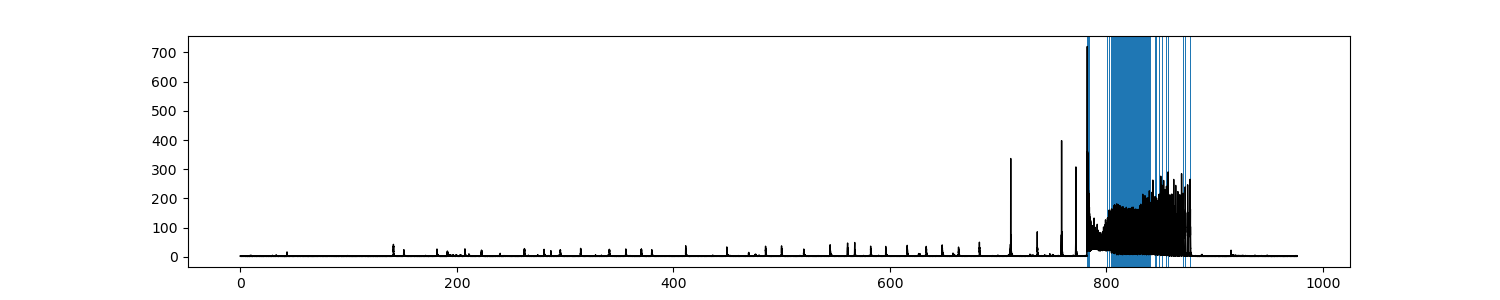

In [85]:

# detection_params = {'min_separation':50,'threshold_std':1,'smoothing_sigma':1000}
avg_ =np.mean(envelope,1)#[0:int(781/(1/subsampling_rate))]#np.mean(filt[:,regions==region],1)# np.mean(envelope,1)#
env,windows,intervals = detect_burst_events(avg_*adc_step*mv_scale_factor, threshold_std=3, min_separation=1000,dt=1/subsampling_rate,smoothing_sigma=100)

plt.figure(figsize=(15,3))
plt.plot(np.arange(0,len(avg_))*(1/subsampling_rate),(avg_*adc_step)*mv_scale_factor,'-',linewidth = 1,color='k'),#);

[plt.axvspan(b[0],b[1]) for b in intervals];

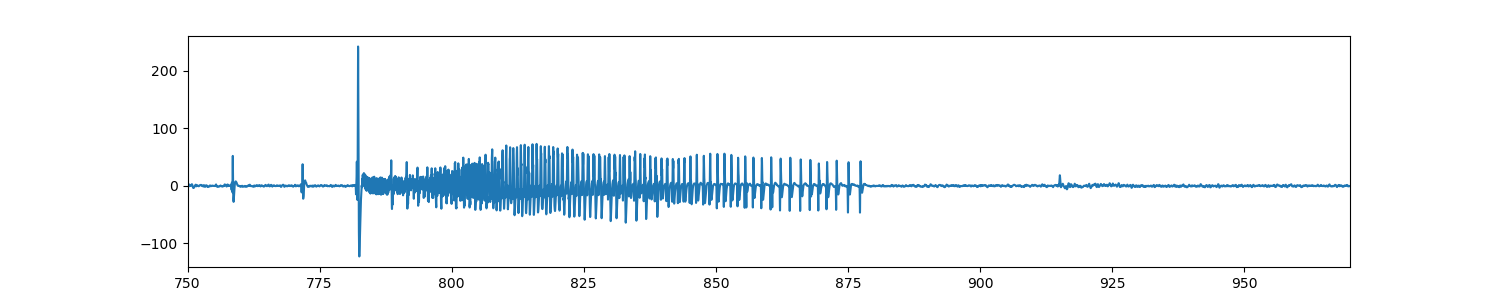

In [91]:
plt.figure(figsize=(15,3))
plt.plot(np.arange(0,len(filt[:]))*(1/(subsampling_rate)),gaussian_filter1d(filt[:,regions==region][:,50]*adc_step*mv_scale_factor,50))
# [plt.axvspan(b[0],b[1]) for b in na(intervals)];
plt.xlim([750,750+220])
plt.show()
# plt.savefig('hpc_het_large_event.pdf')
# plt.savefig('hpc_wt_large_event.pdf')

In [39]:
filt[:,regions==region]

array([], shape=(2017171, 0, 122), dtype=float32)

In [228]:
# manual = [[29.5, 42.5],[567.9,584.2],[1105,1118]]
# windows,intervals = np.nan,np.nan

In [229]:
len(windows)

16

In [298]:
reviewer = BurstBatchReviewer(events=windows, dt=0.0004)

Label(value='')

Output()

In [1]:
subsampling_rate/10

NameError: name 'subsampling_rate' is not defined

In [299]:
aind = np.array(reviewer.accepted_indices)
windows = [w for i,w in enumerate(windows) if i in aind]
intervals = [w for i,w in enumerate(intervals) if i in aind]
# channels = [w for i,w in enumerate(channels) if i in aind]
# intervals =na(all_windows)[aind]
# channels =na(channels)[aind]

In [268]:
# avg_ =np.mean(envelope,1)

In [269]:
# plt.figure()
# plt.plot(avg_[int(781*(subsampling_rate)):int(880*(subsampling_rate))])

In [270]:
# windows.append(avg_[int(781*(subsampling_rate)):int(880*(subsampling_rate))])

In [271]:
# intervals = []
# intervals.extend(manual)
# windows = []
# for inter in intervals:
#     windows.append(avg_[int(inter[0]*(subsampling_rate)):int(inter[1]*(subsampling_rate))])

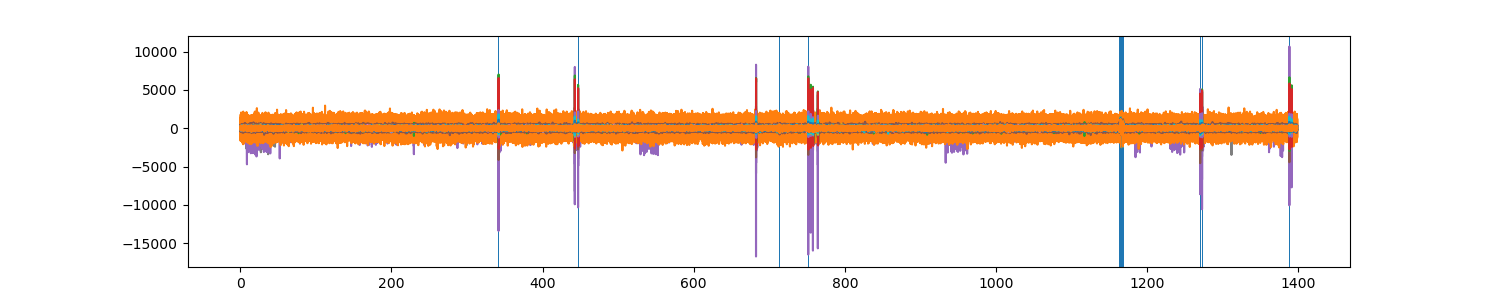

In [300]:
plt.figure(figsize=(15,3))
plt.plot(np.arange(0,len(filt[::10]))*(1/(subsampling_rate/10)),filt[::10,regions==region])
[plt.axvspan(b[0],b[1]) for b in na(intervals)];
plt.show()

In [302]:
# manual = [[37.4,38.4],[97,99],[135.7,136.7],[179,180],[181.8,182.9],[292.6,416.5],[970,971.6],[1040,1041.5],[1230,1231]]

# intervals = []
# intervals.extend(manual)
# windows = []
# for inter in intervals:
#     windows.append(avg_[int(inter[0]*(subsampling_rate)):int(inter[1]*(subsampling_rate))])

In [168]:
regions

array(['hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc',
       'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc'],
      dtype=object)

In [ ]:

# windows,intervals = np.nan,np.nan

In [284]:
rec_table.loc[idx].genotype

'mut'

In [301]:
detected_evetns = pd.DataFrame({'date':rec_table.loc[idx].date,
              'file_name':rec_table.loc[idx].file_name,
              'genotype':rec_table.loc[idx].genotype,
              'slice_number':rec_table.loc[idx].slice_number,
              'channels':[np.where(regions==region)[0]],
              'windows':[windows],
             'intervals':[intervals],
              'region':region })

detected_evetns.to_csv('../data/KCNQ/detected_events/'+'detected_events_'+str(region)+'_'+file_name)

In [362]:
file_name

'KCNQ_17-01-25_slice1_2025-01-17T16-39-53McsRecording.h5_filtered.h5'

In [367]:
# Quick analysis 
region = 'hpc'

rates = []
gen =[]
slicen = []
regions = []
for idx in range(14):
    # try:
    detection_path = '/mnt/server_epl/KCNQ/MEAdata/img/'+rec_table.iloc[idx].electrodes
    file_name = str(rec_table.loc[idx].file_name)
    try:
        detected_events = pd.read_csv('../data/KCNQ/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
        target_file = '/mnt/server_epl/KCNQ/MEAdata/filt/'+file_name#os.path.join(filt_path,filt_file_name).replace('\\','/')
        gen.append(rec_table.loc[idx].genotype)
        slicen.append(rec_table.loc[idx].slice_number)
        with h5py.File(target_file, 'r') as f:
            # print(f.keys())
            
            # subsampling_rate = int(f['resampled_rate'])
                # subsampling_rate = f['resampled_rate']
            subsampling_rate = na(f['resampled_rate'])
            print(na(f['data'].shape[0],dtype=int),subsampling_rate)
            length = na(f['data'].shape[0],dtype=int)*(1/subsampling_rate)
            rates.append(len(detected_events['intervals'])/length)
            regions.append(region)
        
    except:
        pass
        

330167 1600
827835 1600
2327671 1600
1561837 1600
1992582 1600
2030334 1600
2346309 1600
2017171 1600
2237671 1600


In [378]:
file_name = str(rec_table.loc[4].file_name)

pd.read_csv('../data/KCNQ/detected_events/'+'detected_events_'+'ctx'+'_'+file_name)


,Unnamed: 0,date,file_name,genotype,slice_number,channels,windows,intervals,region
0,0,17.01.25,KCNQ_17-01-25_slice 5_2025-01-17T21-17-46McsRe...,WT,slice5,[27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 ...,"[array([3.96186099, 4.54457101, 5.10661567, .....","[(np.float64(433.27625), np.float64(435.428750...",ctx


In [380]:
file_name = str(rec_table.loc[4].file_name)

detected_events= pd.read_csv('../data/KCNQ/detected_events/'+'detected_events_'+'hpc'+'_'+file_name)


In [391]:
import ast



np.int64(0)

In [290]:
[np.diff(intervals_array)<1]

[array([[ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [ True],
        [ True],
        [ True]])]

In [292]:
# Quick analysis 
region = 'ctx'

rates = []
gen =[]
slicen = []
regions_ = []
large_events =[]
durations = []
n_events =[]
for idx in range(14):
    # try:
    detection_path = '/mnt/server_epl/KCNQ/MEAdata/img/'+rec_table.iloc[idx].electrodes
    file_name = str(rec_table.loc[idx].file_name)

    # detected_evetns.to_csv('../data/KCNQ/detected_events/'+'detected_events_'+file_name)
    try:
        detected_events = pd.read_csv('../data/KCNQ/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
        target_file = '/mnt/server_epl/KCNQ/MEAdata/filt/'+file_name#os.path.join(filt_path,filt_file_name).replace('\\','/')
        
        with h5py.File(target_file, 'r') as f:
            # print(f.keys())
            
            # subsampling_rate = int(f['resampled_rate'])
                # subsampling_rate = f['resampled_rate']
            subsampling_rate = na(f['resampled_rate'])
            print(na(f['data'].shape[0],dtype=int),subsampling_rate)
            length =float(na(f['data'].shape[0],dtype=int)*(1/subsampling_rate))

            s = na(detected_events['intervals'])[0]
            s_clean = s.replace('np.float64', '')
            
            # 3. Safely evaluate the list of tuples
            intervals = ast.literal_eval(s_clean)
            
            # 4. Convert to NumPy array
            intervals_array = np.array(intervals)
            
            rates.append(np.sum(np.diff(intervals_array)<1)/length)
            
            regions_.append(region)
            gen.append(rec_table.loc[idx].genotype)
            slicen.append(rec_table.loc[idx].slice_number)
            large_events.append(np.max(np.diff(intervals)))
            durations.append(np.mean(np.diff(intervals)))
            n_events.append(len(intervals))
        
    except:
        pass


region = 'hpc'

for idx in range(14):
    # try:
    detection_path = '/mnt/server_epl/KCNQ/MEAdata/img/'+rec_table.iloc[idx].electrodes
    file_name = str(rec_table.loc[idx].file_name)

    # detected_evetns.to_csv('../data/KCNQ/detected_events/'+'detected_events_'+file_name)
    try:
        detected_events = pd.read_csv('../data/KCNQ/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
        target_file = '/mnt/server_epl/KCNQ/MEAdata/filt/'+file_name#os.path.join(filt_path,filt_file_name).replace('\\','/')
        
        with h5py.File(target_file, 'r') as f:
            # print(f.keys())
            
            # subsampling_rate = int(f['resampled_rate'])
                # subsampling_rate = f['resampled_rate']
            subsampling_rate = na(f['resampled_rate'])
            print(na(f['data'].shape[0],dtype=int),subsampling_rate)
            length =float(na(f['data'].shape[0],dtype=int)*(1/subsampling_rate))

            s = na(detected_events['intervals'])[0]
            s_clean = s.replace('np.float64', '')
            
            # 3. Safely evaluate the list of tuples
            intervals = ast.literal_eval(s_clean)
            
            # 4. Convert to NumPy array
            intervals_array = np.array(intervals)
            # rates.append(len(na(intervals_array))/length)
            # rates.append(len(na(intervals_array)[np.diff(intervals_array)<1])/length)
            rates.append(np.sum(np.diff(intervals_array)<1)/length)
            regions_.append(region)
            gen.append(rec_table.loc[idx].genotype)
            slicen.append(rec_table.loc[idx].slice_number)
            large_events.append(np.max(np.diff(intervals)))        
            durations.append(np.mean(np.diff(intervals)))
            n_events.append(len(intervals))
    except:
        pass



330167 1600
827835 1600
2327671 1600
1992582 1600
2030334 1600
2346309 1600
1176836 1600
2017171 1600
330167 1600
827835 1600
2327671 1600
1561837 1600
1992582 1600
2030334 1600
2346309 1600
2017171 1600
2237671 1600


In [105]:
durations

[np.float64(1.6328125),
 np.float64(0.47243534482759314),
 np.float64(1.6971875000000125),
 np.float64(14.100000000000023),
 np.float64(9.589166666666642),
 np.float64(1.2044791666666692),
 np.float64(0.3458277027026887),
 np.float64(1.6181249999999956),
 np.float64(0.4149273255813963),
 np.float64(0.35714285714284494),
 np.float64(3.382518939393934),
 np.float64(0.6017386363636453),
 np.float64(0.4496826923076922),
 np.float64(0.9728855721393004),
 np.float64(14.899999999999999),
 np.float64(0.7297222222222154)]

In [294]:
df = pd.DataFrame({'genotype':gen,'rate':rates,'slice':slicen,'regions':regions_,'large_events':large_events,'meanDur':durations,'n_events':n_events})

In [232]:
df

,genotype,rate,slice,regions,large_events,meanDur,n_events
0,WT,0.009692,slice1,ctx,1.936875,1.632812,2
1,WT,0.019934,slice3,ctx,1.891875,0.472435,29
2,WT,0.001606,slice5,ctx,2.152500,1.697188,2
3,WT,0.002364,slice6,ctx,16.300000,14.100000,3
4,WT,0.002046,slice8,ctx,14.246875,9.589167,3
5,WT,0.008157,slice9,ctx,2.280000,1.204479,6
6,mut,0.029348,slice4,ctx,2.030625,0.345828,37
7,WT,0.009692,slice1,hpc,1.915000,1.618125,2
8,WT,0.083108,slice2,hpc,0.612500,0.414927,43
9,WT,0.038493,slice3,hpc,0.636250,0.357143,56


<Axes: xlabel='genotype', ylabel='n_events'>

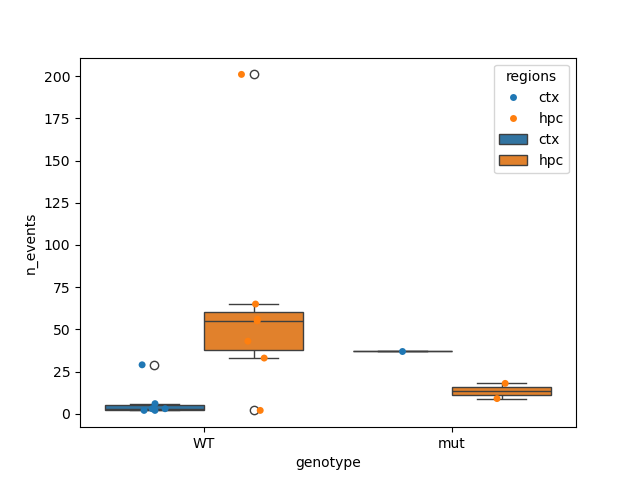

In [288]:
import seaborn as sns
plt.figure()
sns.stripplot(data=df, x='genotype',y='n_events',hue='regions',dodge=True)
sns.boxplot(data=df, x='genotype',y='n_events',hue='regions')

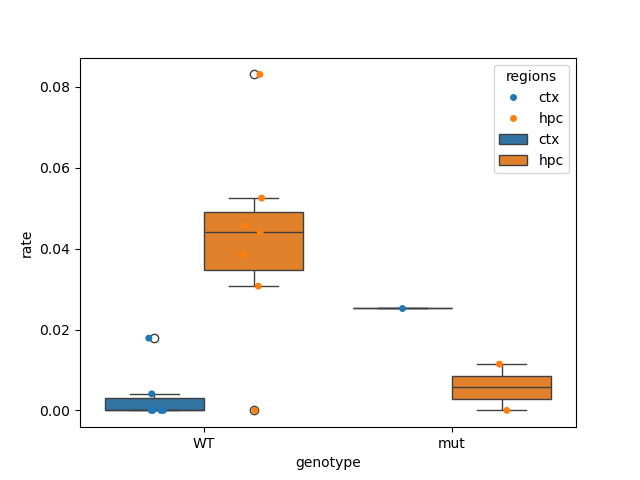

In [295]:
import seaborn as sns
plt.figure()
sns.stripplot(data=df, x='genotype',y='rate',hue='regions',dodge=True)
sns.boxplot(data=df, x='genotype',y='rate',hue='regions')
plt.savefig('LFP_burst_rate.pdf')

<Axes: xlabel='genotype', ylabel='meanDur'>

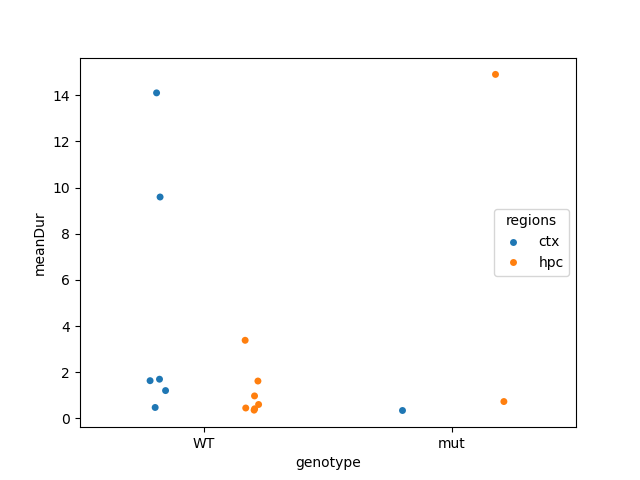

In [113]:
import seaborn as sns
plt.figure()
sns.stripplot(data=df, x='genotype',y='meanDur',hue='regions',dodge=True)
# sns.boxplot(data=df, x='genotype',y='meanDur',hue='regions')

In [234]:
import ast
idx =4
detection_path = '/mnt/server_epl/KCNQ/MEAdata/img/'+rec_table.iloc[idx].electrodes
file_name = str(rec_table.loc[idx].file_name)

# detected_evetns.to_csv('../data/KCNQ/detected_events/'+'detected_events_'+file_name)
region = 'hpc'
detected_events = pd.read_csv('../data/KCNQ/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
target_file = '/mnt/server_epl/KCNQ/MEAdata/filt/'+file_name#os.path.join(filt_path,filt_file_name).replace('\\','/')
s = na(detected_events['intervals'])[0]
s_clean = s.replace('np.float64', '')
# 3. Safely evaluate the list of tuples
intervals = ast.literal_eval(s_clean)

# 4. Convert to NumPy array
intervals_array = np.array(intervals)

In [235]:
detection_path = '/mnt/server_epl/KCNQ/MEAdata/img/'+rec_table.iloc[idx].electrodes
file_name = str(rec_table.loc[idx].file_name)
target_file = '/mnt/server_epl/KCNQ/MEAdata/filt/'+file_name#os.path.join(filt_path,filt_file_name).replace('\\','/')
print(file_name)
ch_detection =pd.read_csv(detection_path)
regions= na(ch_detection['region'])
ch_labels = na(ch_detection['e_label'])
valid_channels = [channels_dict[ch] for ch in ch_labels]

KCNQ_17-01-25_slice 5_2025-01-17T21-17-46McsRecording.h5_filtered.h5


In [236]:
channels = na(valid_channels)[regions==region]

In [250]:
keys = [k for k, v in channels_dict.items() if v == 10]


In [251]:
keys

['F12']

In [277]:
mv_scale_factor =  1000000
event_i = 10
ch_i = 10
with h5py.File(target_file, 'r') as f:
    # print(f.keys())
    # print(f['data'].shape)
    t1,t2= int(intervals_array[event_i][0]*(subsampling_rate)),int(intervals_array[event_i][1]*(subsampling_rate))
    filt = f['data'][t1-400:t2,channels[ch_i]]
    # filt = f['data'][:,channels[ch_i]]
    subsampling_rate = f['resampled_rate']
    subsampling_rate = na(f['resampled_rate'])
    adc_step = na(f['scale'])
    

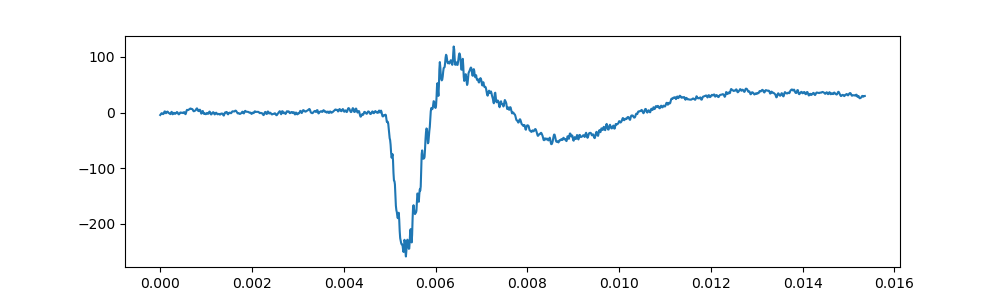

In [278]:
plt.figure(figsize=(10,3))
plt.plot(np.arange(len(filt))*(1/subsampling_rate)/60,filt*adc_step*mv_scale_factor);
# plt.savefig('17-01-25_slice_5_chF12_hpc_bursts.pdf')
# plt.plot(filt[250,:]);


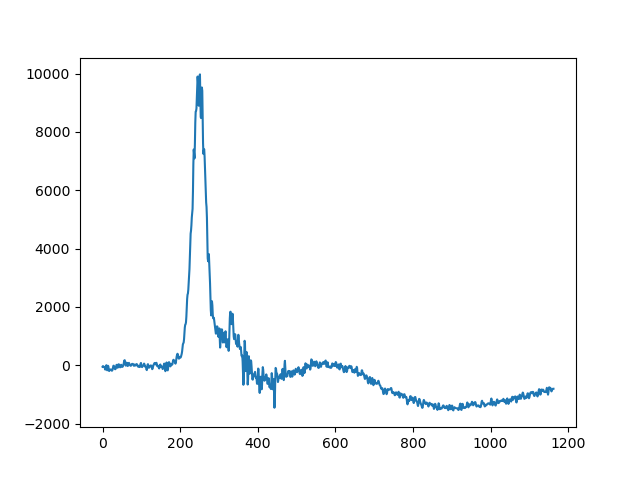

In [273]:
plt.figure()
plt.plot(filt);
# plt.plot(filt[250,:]);

In [185]:
subsampling_rate

array(1600)

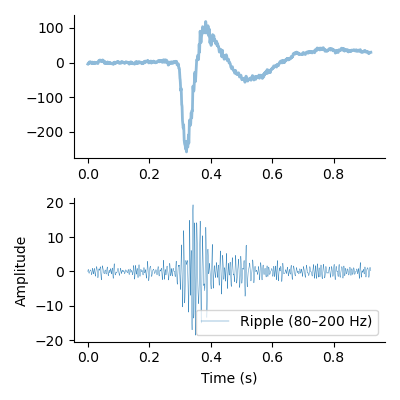

In [284]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# Example signal (replace with your own)
fs = int(subsampling_rate)  # Sampling rate in Hz
t = np.arange(0, len(filt))*(1/fs)  
# signal_raw = np.sin(2*np.pi*80*t) + np.sin(2*np.pi*10*t)  # 80Hz gamma + 10Hz component

# Design bandpass filter (Butterworth)
lowcut = 80
highcut = 200
order = 4
sos = signal.butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')

# Filter the signal
signal_gamma = signal.sosfiltfilt(sos, filt*adc_step*mv_scale_factor)

# Plot
plt.figure(figsize=(4, 4))
plt.subplot(2,1,1)
plt.plot(t, filt*adc_step*mv_scale_factor, label='Raw signal', alpha=0.5,linewidth=2)
sns.despine()
plt.subplot(2,1,2)
plt.plot(t, signal_gamma, label='Ripple (80–200 Hz)', linewidth=0.3)
sns.despine()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('hpc_ripple.pdf')

In [318]:
rates

[]

date                                                     17.01.25
genotype                                                       WT
slice_number                                               slice2
electrodes                 17-01-25_slice2_labeled_electrodes.csv
img_path                                                      NaN
file_name       KCNQ_17-01-25_Slice2_2025-01-17T17-15-11McsRec...
valid                                                         NaN
Comment                                                      2nd 
comment2                                   spiking  acitivty +LFP
comment3                    Here spiking from hpc can be analyzed
Unnamed: 10                                                   NaN
Name: 1, dtype: object